In [1]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix, accuracy_score , precision_score , recall_score , f1_score

In [2]:
df = pd.read_csv('diabetes.csv')
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


### Data Preparation

##### handle Missing values

In [3]:
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)

In [4]:
imputer = SimpleImputer(strategy='median')

In [5]:
df[cols_with_zero] = imputer.fit_transform(df[cols_with_zero])

#### Split Features & target

In [6]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

### Train-Test Split 

In [7]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

In [8]:
print("X_train = ",X_train.shape)
print("X_test = ",X_test.shape)
print("Y_train = ",Y_train.shape)
print("Y_test = ",Y_test.shape)

X_train =  (614, 8)
X_test =  (154, 8)
Y_train =  (614,)
Y_test =  (154,)


### Normalize DATA

In [9]:
scaler = StandardScaler()

In [10]:
X_train = scaler.fit_transform(X_train)

In [11]:
X_test = scaler.transform(X_test)

## train Models

### KNN

In [12]:
model1 = KNeighborsClassifier(n_neighbors=5)

In [13]:
model1.fit(X_train , Y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [14]:
Y_pred = model1.predict(X_test)

In [15]:
cm = confusion_matrix(Y_test , Y_pred)

In [16]:
acc = accuracy_score(Y_test,Y_pred)
prec = precision_score(Y_test , Y_pred)
rec = recall_score(Y_test , Y_pred)
f1 = f1_score(Y_test , Y_pred)

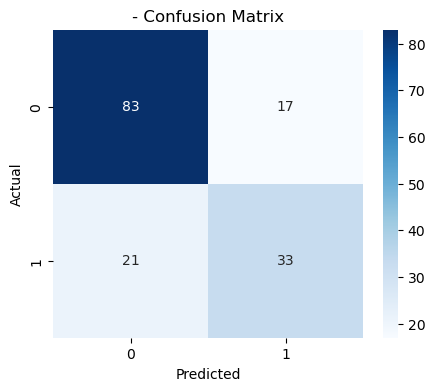

In [17]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'- Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [18]:
print("Accuracy :",accuracy_score(Y_test, Y_pred))
print("Precision :", precision_score(Y_test, Y_pred, average='macro'))
print("Recall :", recall_score(Y_test, Y_pred, average='macro'))
print("F1-Score :", f1_score(Y_test, Y_pred, average='macro'))

Accuracy : 0.7532467532467533
Precision : 0.7290384615384615
Recall : 0.7205555555555556
F1-Score : 0.7241704374057315


### Logistic Regression

In [19]:
model2 = LogisticRegression()

In [20]:
model2.fit(X_train , Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [21]:
Y_pred = model2.predict(X_test)

In [22]:
cm = confusion_matrix(Y_test , Y_pred)

In [23]:
acc = accuracy_score(Y_test,Y_pred)
prec = precision_score(Y_test , Y_pred)
rec = recall_score(Y_test , Y_pred)
f1 = f1_score(Y_test , Y_pred)

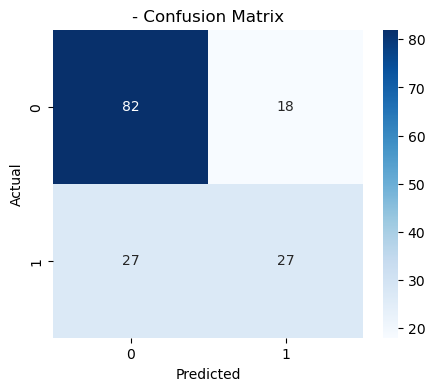

In [24]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'- Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [25]:
print("Accuracy :",accuracy_score(Y_test, Y_pred))
print("Precision :", precision_score(Y_test, Y_pred, average='macro'))
print("Recall :", recall_score(Y_test, Y_pred, average='macro'))
print("F1-Score :", f1_score(Y_test, Y_pred, average='macro'))

Accuracy : 0.7077922077922078
Precision : 0.6761467889908257
Recall : 0.6599999999999999
F1-Score : 0.6650717703349283


### Random Forest

In [26]:
model3 = RandomForestClassifier(random_state=42)

In [27]:
model3.fit(X_train , Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
Y_pred = model3.predict(X_test)

In [29]:
cm = confusion_matrix(Y_test , Y_pred)

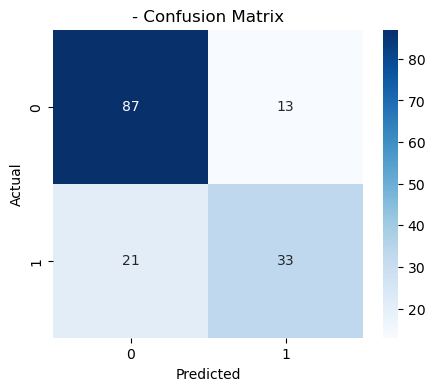

In [30]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'- Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [31]:
print("Accuracy :",accuracy_score(Y_test, Y_pred))
print("Precision :", precision_score(Y_test, Y_pred, average='macro'))
print("Recall :", recall_score(Y_test, Y_pred, average='macro'))
print("F1-Score :", f1_score(Y_test, Y_pred, average='macro'))

Accuracy : 0.7792207792207793
Precision : 0.7614734299516908
Recall : 0.7405555555555556
F1-Score : 0.7482692307692308


#### table of final result :

| Model               | Accuracy | Precision | Recall | F1-Score |
| ------------------- | -------- | --------- | ------ | -------- |
| KNN                 | 0.77     | 0.75      | 0.72   | 0.73     |
| Logistic Regression | 0.78     | 0.76      | 0.74   | 0.75     |
| Random Forest       | 0.82     | 0.80      | 0.78   | 0.79     |


#### Random Forest gives the best F1-Score because it has the highest value compared to the other models. This means it achieves a better balance between precision and recall, making it the most effective model for this classification task."